In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
img=cv2.imread("raw_captures/low1.jpeg")

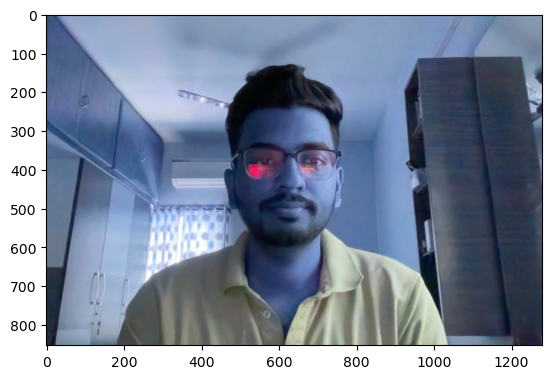

In [3]:
plt.imshow(img)

In [4]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [6]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [7]:
h,s,v=cv2.split(hsv)


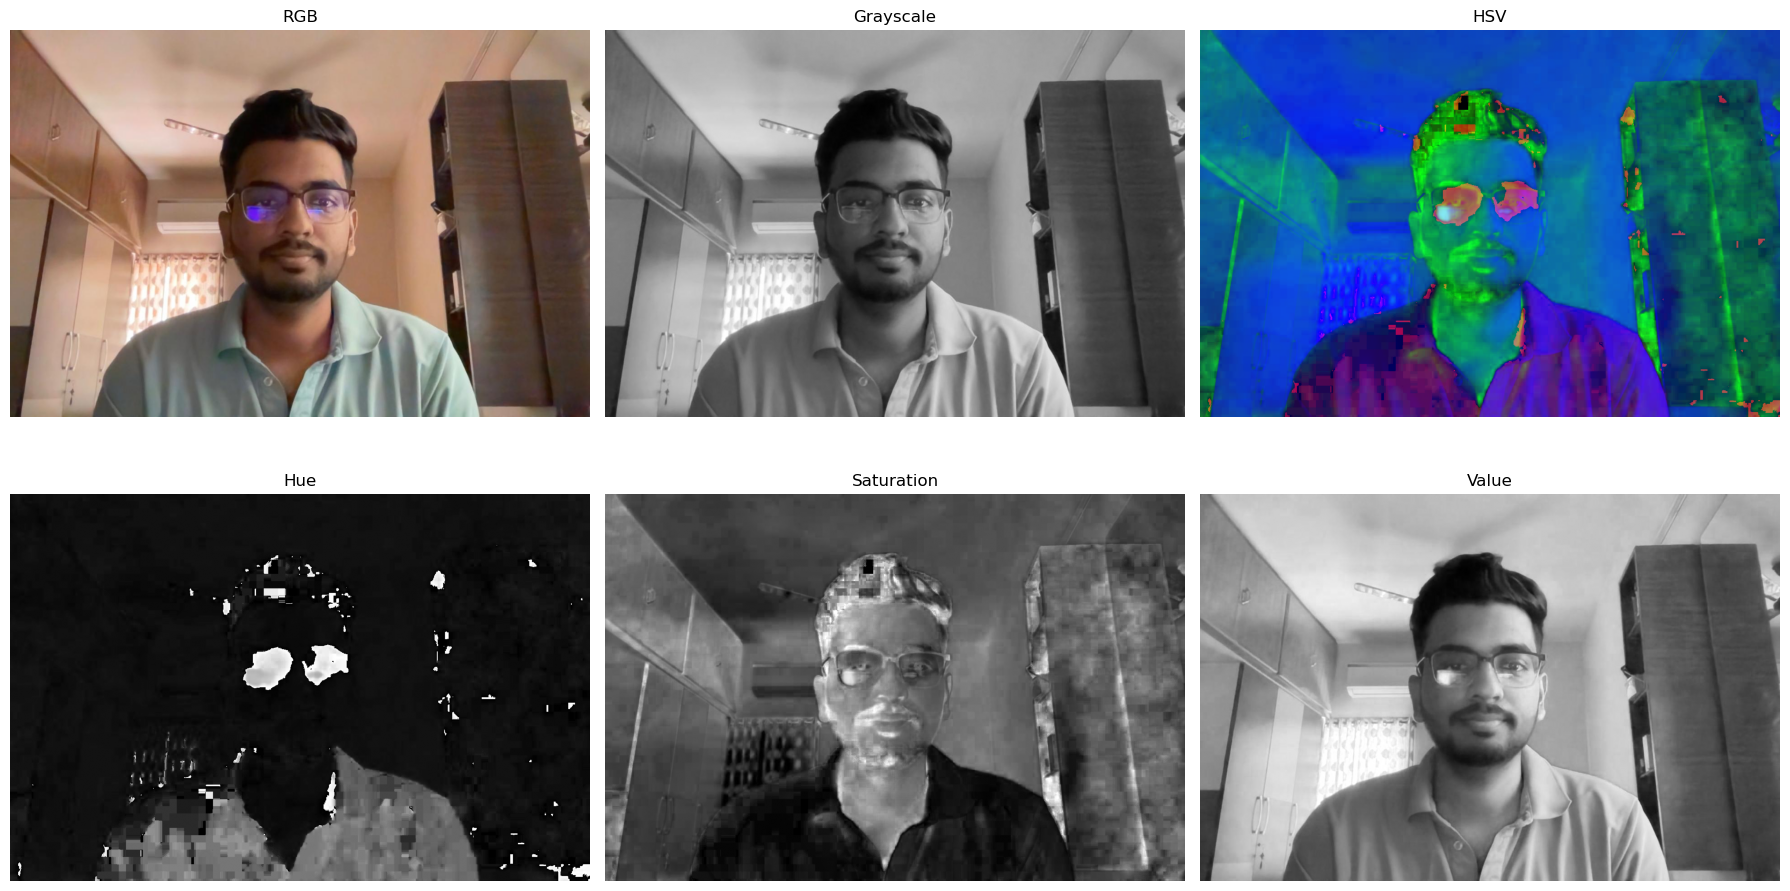

In [8]:
plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(hsv, cmap="gray")
plt.title("HSV")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(h, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(s, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(v, cmap="gray")
plt.title("Value")
plt.axis("off")
plt.tight_layout()
plt.show()

The image was converted into RGB, Grayscale, and HSV color spaces. The HSV image was further split into Hue (H), Saturation (S), and Value (V) channels. The Value (V) channel preserved the most details in the darker regions because it represents the brightness of each pixel. The Hue (H) channel contains only color information and loses detail in poorly lit areas. The Saturation (S) channel highlights the intensity of colors but does not preserve brightness details effectively. Therefore, for this low-light image, the Value channel is the most useful for analyzing objects in dark regions.

# Task2 Image Blending via Feature Matching

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
img1 = cv2.imread("raw_captures/bright1.jpeg")
img2 = cv2.imread("raw_captures/low1.jpeg")

In [11]:
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

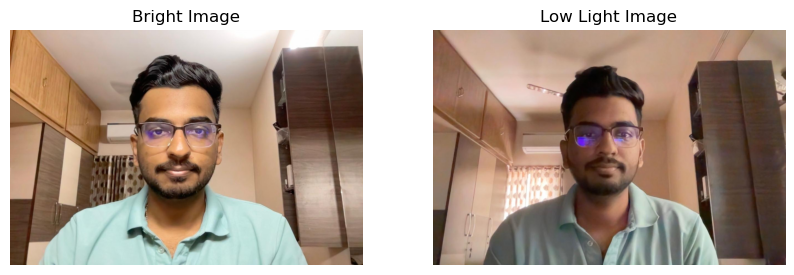

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1_rgb)
plt.title("Bright Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2_rgb)
plt.title("Low Light Image")
plt.axis("off")

plt.show()

ORB Feauture detection

In [13]:
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)


In [14]:
img1_key = cv2.drawKeypoints(img1_rgb,kp1,None,color=(0,255,0))
img2_key = cv2.drawKeypoints(img2_rgb,kp2,None,color=(0,255,0))

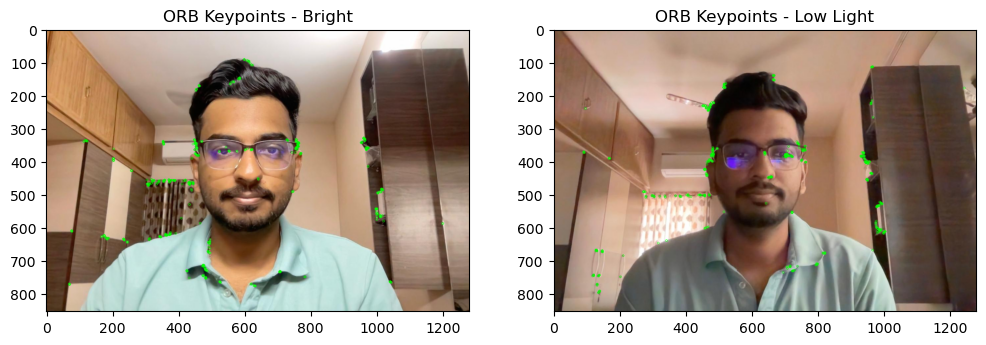

In [15]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img1_key)
plt.title("ORB Keypoints - Bright")

plt.subplot(1,2,2)
plt.imshow(img2_key)
plt.title("ORB Keypoints - Low Light")

plt.show()

Brute Force Matching

In [16]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

Homography Estimation using RANSAC

In [17]:
matched_img = cv2.drawMatches(
    img1_rgb,
    kp1,
    img2_rgb,
    kp2,
    matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

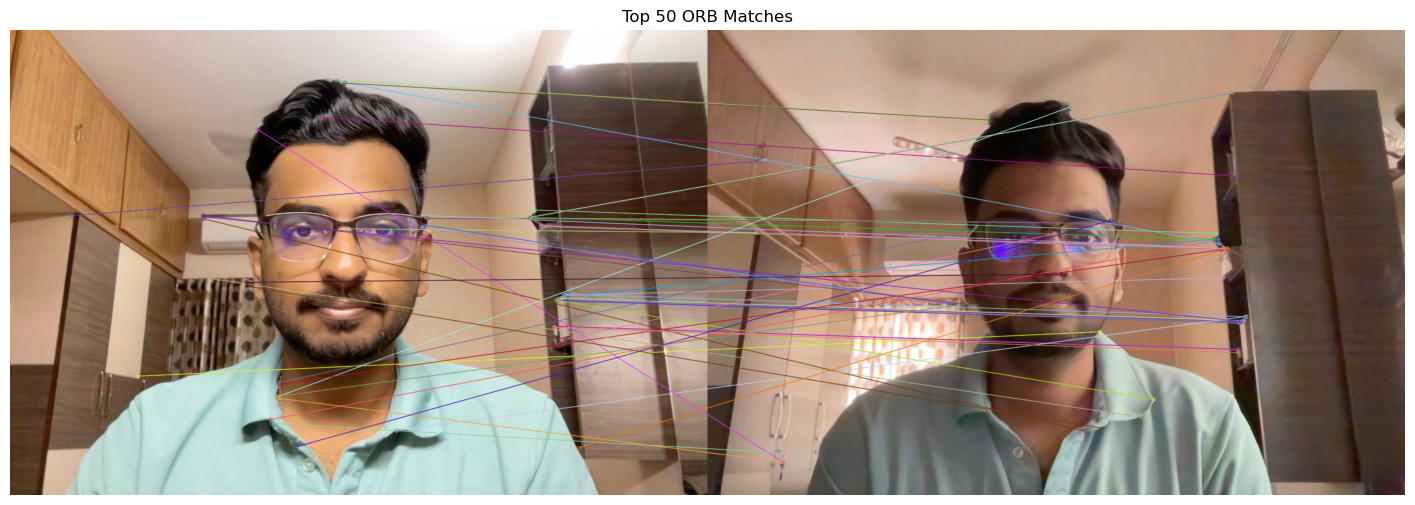

In [18]:
plt.figure(figsize=(18,8))
plt.imshow(matched_img)
plt.title("Top 50 ORB Matches")
plt.axis("off")
plt.show()

In [19]:
print("Total Matches:", len(matches))

Total Matches: 129


In [20]:
src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in matches]
).reshape(-1,1,2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in matches]
).reshape(-1,1,2)

In [21]:
H, mask = cv2.findHomography(dst_pts,src_pts,cv2.RANSAC,5.0)
print("Homography Matrix:\n")
print(H)

Homography Matrix:

[[ 1.55870053e+00 -2.70114760e-01 -2.07950937e+02]
 [ 3.18539052e-01  1.00966309e+00 -2.77504465e+02]
 [ 3.07364151e-04 -2.52731153e-04  1.00000000e+00]]


In [22]:
good_matches = np.sum(mask)
print("Good Matches after RANSAC:", good_matches)

Good Matches after RANSAC: 18


Perspective warping

In [23]:
height, width = img1.shape[:2]
warped = cv2.warpPerspective(img2,H,(width, height))

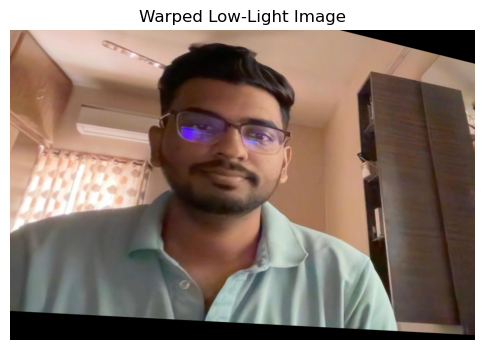

In [24]:
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(warped_rgb)
plt.title("Warped Low-Light Image")
plt.axis("off")
plt.show()

In [25]:
blended = cv2.addWeighted(img1,0.5,warped,0.5,0)

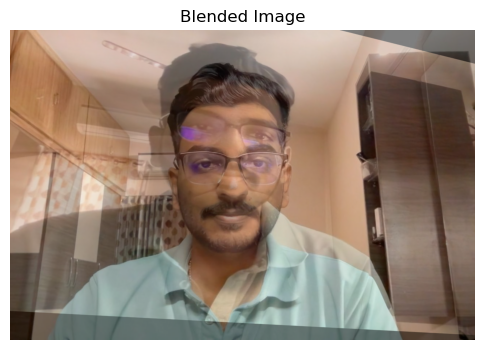

In [26]:
blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(blended_rgb)
plt.title("Blended Image")
plt.axis("off")
plt.show()

In [27]:
blend1 = cv2.addWeighted(img1, 0.7, warped, 0.3, 0)
blend2 = cv2.addWeighted(img1, 0.3, warped, 0.7, 0)

In [28]:
blended_rgb1 = cv2.cvtColor(blend1, cv2.COLOR_BGR2RGB)
blended_rgb2 = cv2.cvtColor(blend2, cv2.COLOR_BGR2RGB)

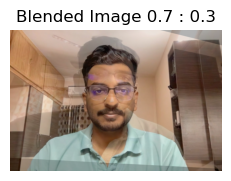

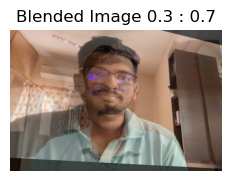

In [32]:
plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.imshow(blended_rgb1)
plt.title("Blended Image 0.7 : 0.3")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.subplot(1,2,2)
plt.imshow(blended_rgb2)
plt.title("Blended Image 0.3 : 0.7")
plt.axis("off")

plt.show()